In [1]:
##KMeans

In [2]:
import pandas as pd
import numpy as np
data =pd.read_csv('data.csv')
data.head()

,V1,V2,labels
0,-2.102279,16.661048,0.0
1,-10.358733,23.263660,0.0
2,2.329603,20.235419,0.0
3,-12.081777,14.782368,0.0
4,0.145015,24.997819,0.0


In [3]:
x=data.drop(['labels'],axis=1)
y=data.loc[:,'labels']

In [4]:
pd.Series(y).value_counts()

labels
0.0    500
1.0    500
2.0    500
Name: count, dtype: int64

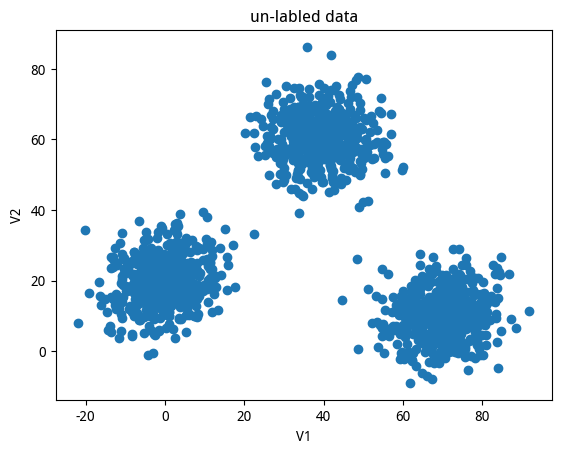

In [5]:
%matplotlib inline
from matplotlib import pyplot as plt
fig1=plt.figure()
plt.scatter(x.loc[:,'V1'],x.loc[:,'V2'])
plt.title("un-labled data")
plt.xlabel('V1')
plt.ylabel('V2')
plt.show()

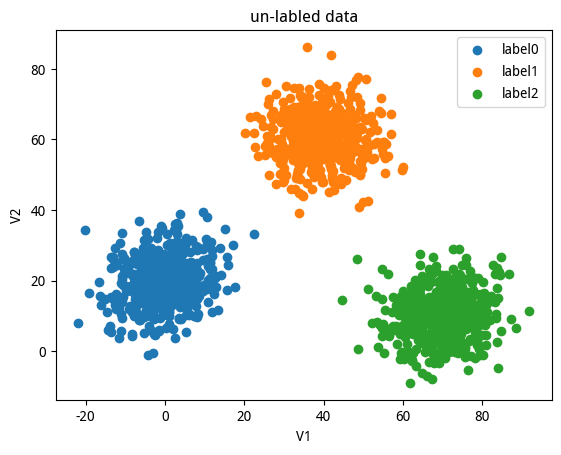

In [6]:
fig2=plt.figure()
label0=plt.scatter(x.loc[:,'V1'][y==0],x.loc[:,'V2'][y==0])
label1=plt.scatter(x.loc[:,'V1'][y==1],x.loc[:,'V2'][y==1])
label2=plt.scatter(x.loc[:,'V1'][y==2],x.loc[:,'V2'][y==2])
plt.legend((label0,label1,label2),('label0','label1','label2'))
plt.title("un-labled data")
plt.xlabel('V1')
plt.ylabel('V2')
plt.show()

In [7]:
from sklearn.cluster import KMeans
KM=KMeans(n_clusters=3,random_state=0)
KM.fit(x)

#set OMP_NUM_THREADS=6
#可能会出现内存泄漏，需要更改环境变量，再cmd中更改再启动jupyter notebook

,n_clusters,3
,init,'k-means++'
,n_init,'auto'
,max_iter,300
,tol,0.0001
,verbose,0
,random_state,0
,copy_x,True
,algorithm,'lloyd'


In [8]:
centers=KM.cluster_centers_
KM.cluster_centers_

array([[39.29437738, 60.05935469],
       [69.94813535, 10.15817506],
       [-0.17653069, 20.13708152]])

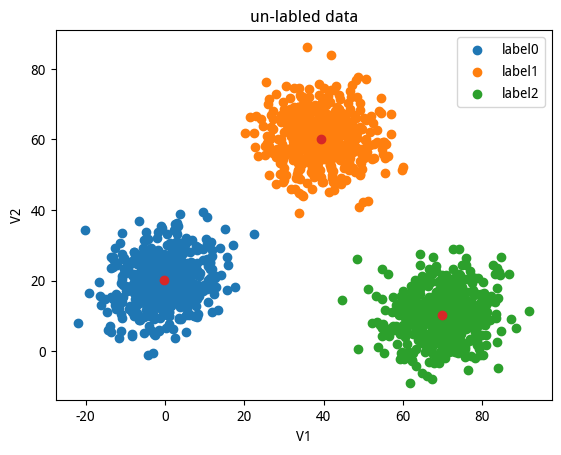

In [9]:
fig3=plt.figure()

label0=plt.scatter(x.loc[:,'V1'][y==0],x.loc[:,'V2'][y==0])
label1=plt.scatter(x.loc[:,'V1'][y==1],x.loc[:,'V2'][y==1])
label2=plt.scatter(x.loc[:,'V1'][y==2],x.loc[:,'V2'][y==2])
plt.legend((label0,label1,label2),('label0','label1','label2'))
plt.title("un-labled data")
plt.xlabel('V1')
plt.ylabel('V2')

plt.scatter(centers[:,0],centers[:,1])
plt.show()

In [10]:
y_predict_test=KM.predict([[80,60]])
print(y_predict_test)

[0]


/home/hexiaoya/miniconda3/envs/ai/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(


In [11]:
y_predict=KM.predict(x)
print(pd.Series(y_predict).value_counts(),pd.Series(y).value_counts())

2    500
0    500
1    500
Name: count, dtype: int64 labels
0.0    500
1.0    500
2.0    500
Name: count, dtype: int64


In [12]:
from sklearn.metrics import accuracy_score
accuracy=accuracy_score(y,y_predict)
print(accuracy)

0.0


In [13]:
y_corrected=[]
for i in y_predict:
    if i==0:
        y_corrected.append(1)
    elif i==1:
        y_corrected.append(2)
    else:
        y_corrected.append(0)
print(pd.Series(y_corrected).value_counts())

0    500
1    500
2    500
Name: count, dtype: int64


In [14]:
print(accuracy_score(y,y_corrected))

1.0


In [15]:
##KNN

In [16]:
from sklearn.neighbors import KNeighborsClassifier 
KNN = KNeighborsClassifier(n_neighbors=3) 
KNN.fit(x,y)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [17]:
y_predict_knn_test = KNN.predict([[80,60]]) 
y_predict_knn = KNN.predict(x) 
print(y_predict_knn_test) 
print('knn accuracy:',accuracy_score(y,y_predict_knn))

[1.]
knn accuracy: 1.0


/home/hexiaoya/miniconda3/envs/ai/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


In [18]:
print(pd.Series(y_predict_knn).value_counts(),pd.Series(y).value_counts())

0.0    500
1.0    500
2.0    500
Name: count, dtype: int64 labels
0.0    500
1.0    500
2.0    500
Name: count, dtype: int64


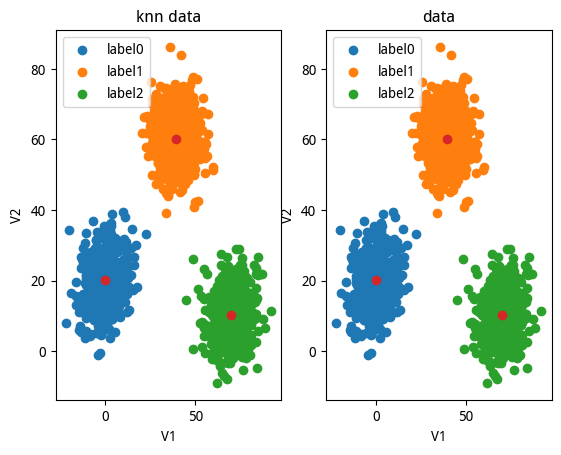

In [19]:
fig4=plt.subplot(121)

label0=plt.scatter(x.loc[:,'V1'][y_predict_knn==0],x.loc[:,'V2'][y_predict_knn==0])
label1=plt.scatter(x.loc[:,'V1'][y_predict_knn==1],x.loc[:,'V2'][y_predict_knn==1])
label2=plt.scatter(x.loc[:,'V1'][y_predict_knn==2],x.loc[:,'V2'][y_predict_knn==2])

plt.legend((label0,label1,label2),('label0','label1','label2'))
plt.title("knn data")
plt.xlabel('V1')
plt.ylabel('V2')
plt.scatter(centers[:,0],centers[:,1])

fig5=plt.subplot(122)

label0=plt.scatter(x.loc[:,'V1'][y==0],x.loc[:,'V2'][y==0])
label1=plt.scatter(x.loc[:,'V1'][y==1],x.loc[:,'V2'][y==1])
label2=plt.scatter(x.loc[:,'V1'][y==2],x.loc[:,'V2'][y==2])

plt.legend((label0,label1,label2),('label0','label1','label2'))
plt.title("data")
plt.xlabel('V1')
plt.ylabel('V2')
plt.scatter(centers[:,0],centers[:,1])

plt.show()

In [20]:
#Meanshift

In [21]:
from sklearn.cluster import MeanShift,estimate_bandwidth
bw=estimate_bandwidth(x,n_samples=500)
ms=MeanShift(bandwidth=bw)
ms.fit(x)

,bandwidth,20.046651833779155
,seeds,None
,bin_seeding,False
,min_bin_freq,1
,cluster_all,True
,n_jobs,None
,max_iter,300


In [22]:
y_predict_ms=ms.predict(x)
print(pd.Series(y_predict_ms).value_counts())

0    500
2    500
1    500
Name: count, dtype: int64


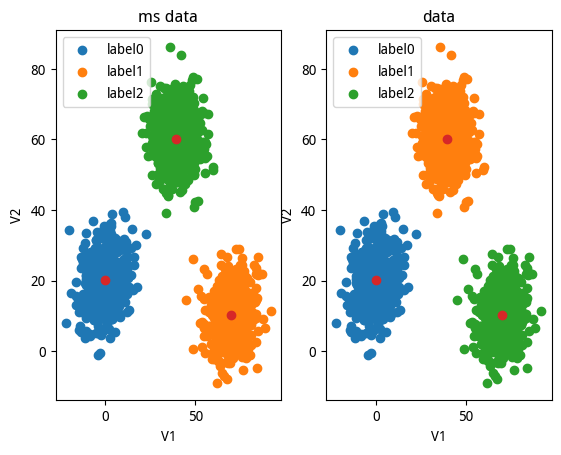

In [23]:
fig6=plt.subplot(121)

label0=plt.scatter(x.loc[:,'V1'][y_predict_ms==0],x.loc[:,'V2'][y_predict_ms==0])
label1=plt.scatter(x.loc[:,'V1'][y_predict_ms==1],x.loc[:,'V2'][y_predict_ms==1])
label2=plt.scatter(x.loc[:,'V1'][y_predict_ms==2],x.loc[:,'V2'][y_predict_ms==2])

plt.legend((label0,label1,label2),('label0','label1','label2'))
plt.title("ms data")
plt.xlabel('V1')
plt.ylabel('V2')
plt.scatter(centers[:,0],centers[:,1])

fig7=plt.subplot(122)

label0=plt.scatter(x.loc[:,'V1'][y==0],x.loc[:,'V2'][y==0])
label1=plt.scatter(x.loc[:,'V1'][y==1],x.loc[:,'V2'][y==1])
label2=plt.scatter(x.loc[:,'V1'][y==2],x.loc[:,'V2'][y==2])

plt.legend((label0,label1,label2),('label0','label1','label2'))
plt.title("data")
plt.xlabel('V1')
plt.ylabel('V2')
plt.scatter(centers[:,0],centers[:,1])

plt.show()

In [24]:
y_corrected_ms=[]
for i in y_predict_ms:
    if i==0:
        y_corrected_ms.append(0)
    elif i==1:
        y_corrected_ms.append(2)
    else:
        y_corrected_ms.append(1)
print(pd.Series(y_corrected_ms).value_counts())

0    500
1    500
2    500
Name: count, dtype: int64


In [25]:
y_corrected_ms=np.array(y_corrected_ms)

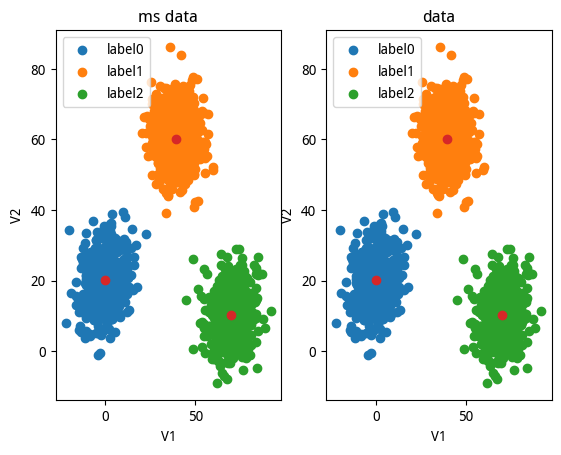

In [26]:
fig8=plt.subplot(121)

label0=plt.scatter(x.loc[:,'V1'][y_corrected_ms==0],x.loc[:,'V2'][y_corrected_ms==0])
label1=plt.scatter(x.loc[:,'V1'][y_corrected_ms==1],x.loc[:,'V2'][y_corrected_ms==1])
label2=plt.scatter(x.loc[:,'V1'][y_corrected_ms==2],x.loc[:,'V2'][y_corrected_ms==2])

plt.legend((label0,label1,label2),('label0','label1','label2'))
plt.title("ms data")
plt.xlabel('V1')
plt.ylabel('V2')
plt.scatter(centers[:,0],centers[:,1])

fig9=plt.subplot(122)

label0=plt.scatter(x.loc[:,'V1'][y==0],x.loc[:,'V2'][y==0])
label1=plt.scatter(x.loc[:,'V1'][y==1],x.loc[:,'V2'][y==1])
label2=plt.scatter(x.loc[:,'V1'][y==2],x.loc[:,'V2'][y==2])

plt.legend((label0,label1,label2),('label0','label1','label2'))
plt.title("data")
plt.xlabel('V1')
plt.ylabel('V2')
plt.scatter(centers[:,0],centers[:,1])

plt.show()